<a href="https://colab.research.google.com/github/Dima-BR/machine-learning-projects/blob/main/Diabetes_Predection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Predection

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# For modling
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, recall_score, f1_score

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from collections import Counter

plt.style.use('fivethirtyeight')

import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes (3).csv


In [3]:
df = pd.read_csv('/content/diabetes.csv')

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.shape

(768, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [8]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [9]:
df.duplicated().sum()

np.int64(0)

# Analysis

In [10]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


<Axes: >

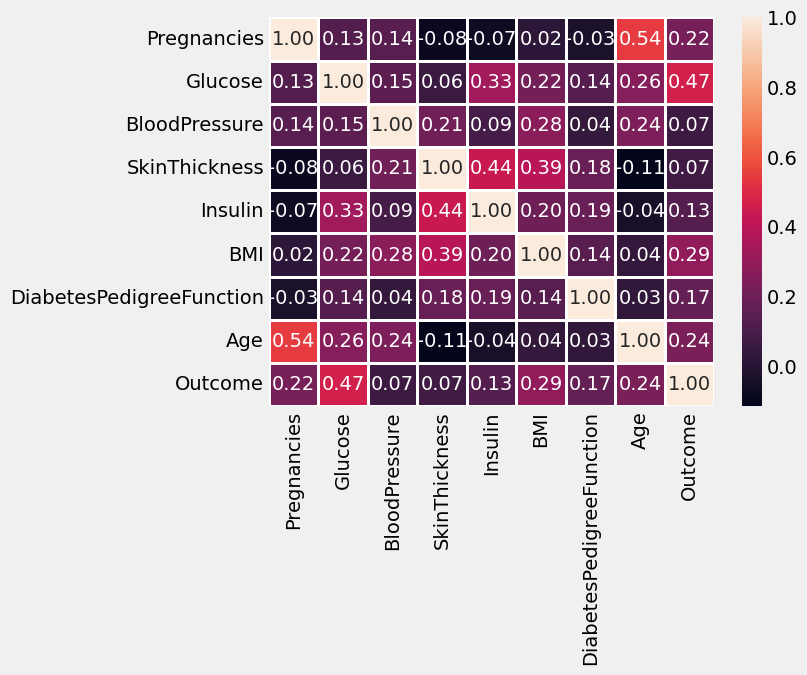

In [11]:
sns.heatmap(df.corr(), annot=True, fmt='0.2f', linewidths=.8)

<Axes: xlabel='Outcome', ylabel='count'>

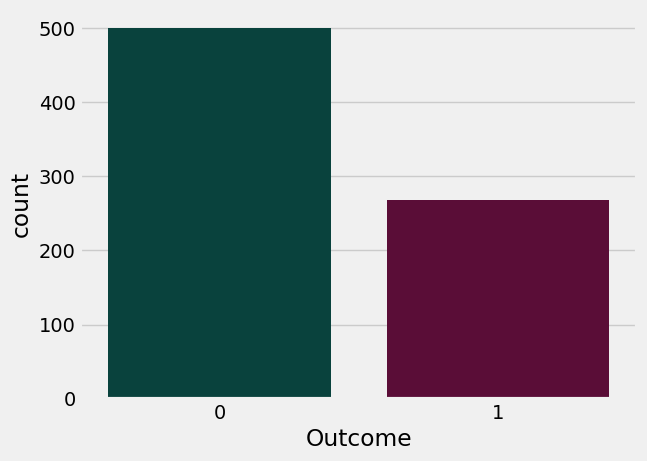

In [12]:
sns.countplot(x='Outcome', data=df, palette=['#004b45', '#670038'])

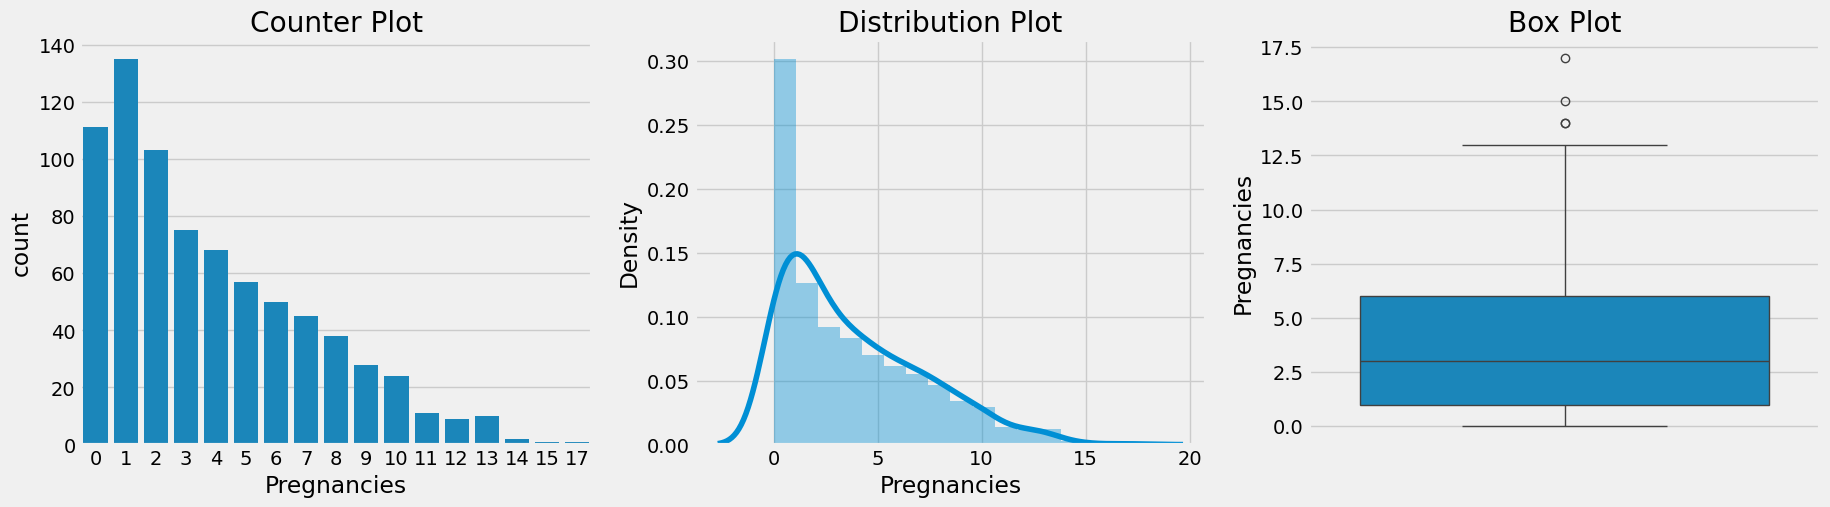

In [13]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 3, 1)
plt.title("Counter Plot")
sns.countplot(x='Pregnancies', data=df)


plt.subplot(1, 3, 2)
plt.title("Distribution Plot")
sns.distplot(df['Pregnancies'])

plt.subplot(1, 3, 3)
plt.title("Box Plot")
sns.boxplot(y=df['Pregnancies'])


plt.show()

<Axes: ylabel='Age'>

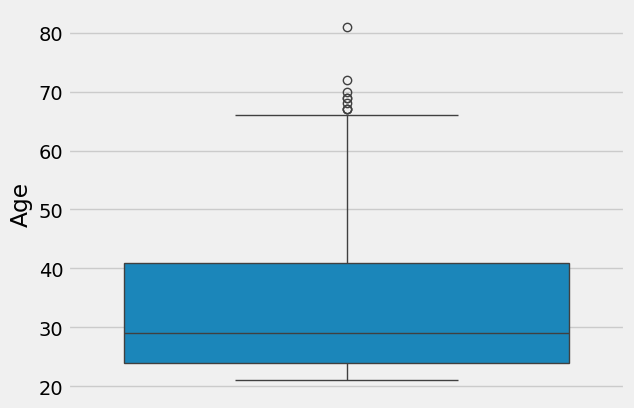

In [14]:
sns.boxplot(df.Age)

# Models

In [38]:
x = df.drop('Outcome', axis=1)

y = df['Outcome']

In [39]:
rom = RandomOverSampler(random_state=41)
x_res, y_res = rom.fit_resample(x, y)

In [40]:
print('old shape data',format(Counter(y)))
print('new shape data',format(Counter(y_res)))

old shape data Counter({0: 500, 1: 268})
new shape data Counter({1: 500, 0: 500})


In [41]:
# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,  random_state=42)


In [42]:
model1= LogisticRegression()
model2 = SVC()
model3 = RandomForestClassifier(n_estimators=100, class_weight='balanced')
model4 = GradientBoostingClassifier(n_estimators=1000)

In [43]:
models = ['LogisticRegression', 'SVC', 'RandomForestClassifier', 'GradientBoostingClassifier']
# models = [LogisticRegression(), SVC(), RandomForestClassifier()]
r1 = []
r2 = []
r3 = []
r4 = []

In [44]:
def all_metrics(model):
    # Train
    model.fit(x_train, y_train)

    # predect
    pre = model.predict(x_test)

    # calculate the evaluations
    acc = accuracy_score(y_test, pre)
    recall = recall_score(y_test, pre, average='weighted')
    f1 = f1_score(y_test, pre, average='weighted')

    r1.append(acc)
    r2.append(recall)
    r3.append(f1)


    print(f"Model: {type(model).__name__}")
    print("-" * 30)
    print(f"Accuracy Score : {acc:.4f}")
    print(f"Recall Score   : {recall:.4f}")
    print(f"F1 Score       : {f1:.4f}")
    print("-" * 30)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pre))
    print("\nClassification Report:")
    print(classification_report(y_test, pre))

    sns.heatmap(confusion_matrix(y_test, pre), annot=True)

## Model_1: **LogisticRegression**

Model: LogisticRegression
------------------------------
Accuracy Score : 0.7403
Recall Score   : 0.7403
F1 Score       : 0.7413
------------------------------
Confusion Matrix:
[[78 21]
 [19 36]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.79      0.80        99
           1       0.63      0.65      0.64        55

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154



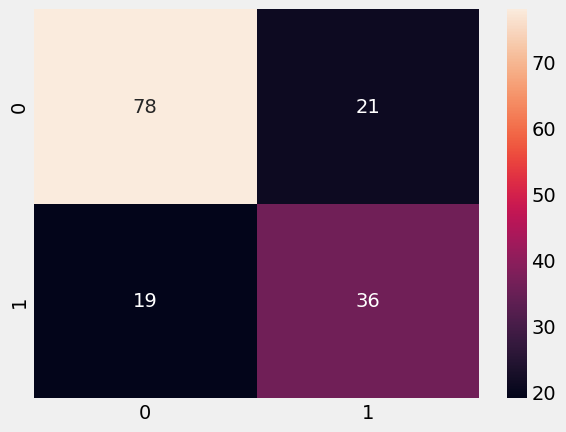

In [45]:
# model1= LogisticRegression()
all_metrics(model1)


## Model_2: SVM

Model: SVC
------------------------------
Accuracy Score : 0.7662
Recall Score   : 0.7662
F1 Score       : 0.7586
------------------------------
Confusion Matrix:
[[87 12]
 [24 31]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.88      0.83        99
           1       0.72      0.56      0.63        55

    accuracy                           0.77       154
   macro avg       0.75      0.72      0.73       154
weighted avg       0.76      0.77      0.76       154



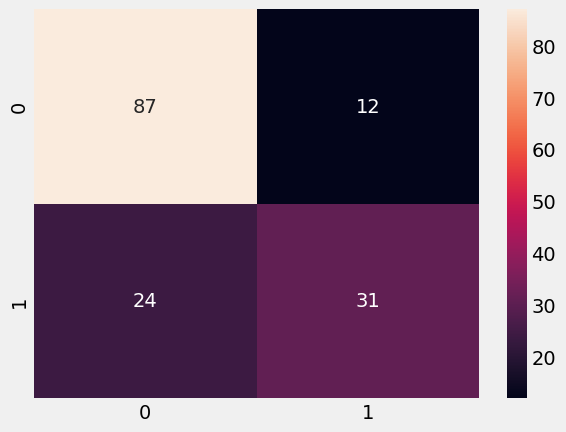

In [46]:
# model2 = SVC()
all_metrics(model2)

## Model_3: **RandomForestClassifier**

Model: RandomForestClassifier
------------------------------
Accuracy Score : 0.7403
Recall Score   : 0.7403
F1 Score       : 0.7403
------------------------------
Confusion Matrix:
[[79 20]
 [20 35]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        99
           1       0.64      0.64      0.64        55

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154



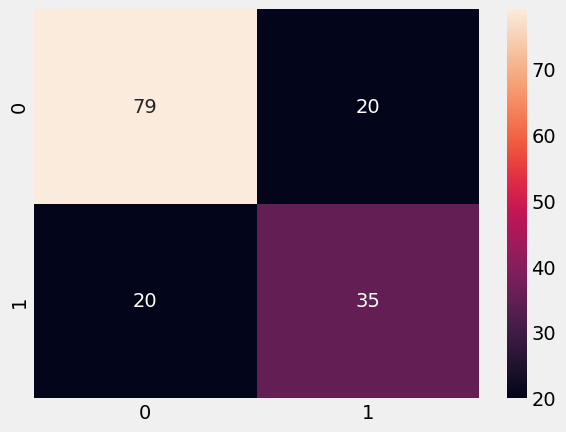

In [47]:
# model3 = RandomForestClassifier()
all_metrics(model3)

## Model_4: **GradientBoostingClassifier**

Model: GradientBoostingClassifier
------------------------------
Accuracy Score : 0.7338
Recall Score   : 0.7338
F1 Score       : 0.7375
------------------------------
Confusion Matrix:
[[74 25]
 [16 39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.75      0.78        99
           1       0.61      0.71      0.66        55

    accuracy                           0.73       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



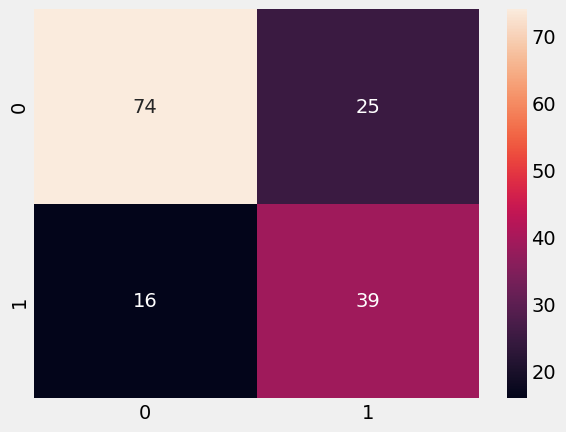

In [48]:
# model4 = GradientBoostingClassifier()
all_metrics(model4)

## Models Comparison

In [49]:
compare= pd.DataFrame({'Algorithem': models, 'Accurecy': r1, 'Recall': r2, 'F1Score': r3})
compare

,Algorithem,Accurecy,Recall,F1Score
0,LogisticRegression,0.740260,0.740260,0.741254
1,SVC,0.766234,0.766234,0.758601
2,RandomForestClassifier,0.740260,0.740260,0.740260
3,GradientBoostingClassifier,0.733766,0.733766,0.737495


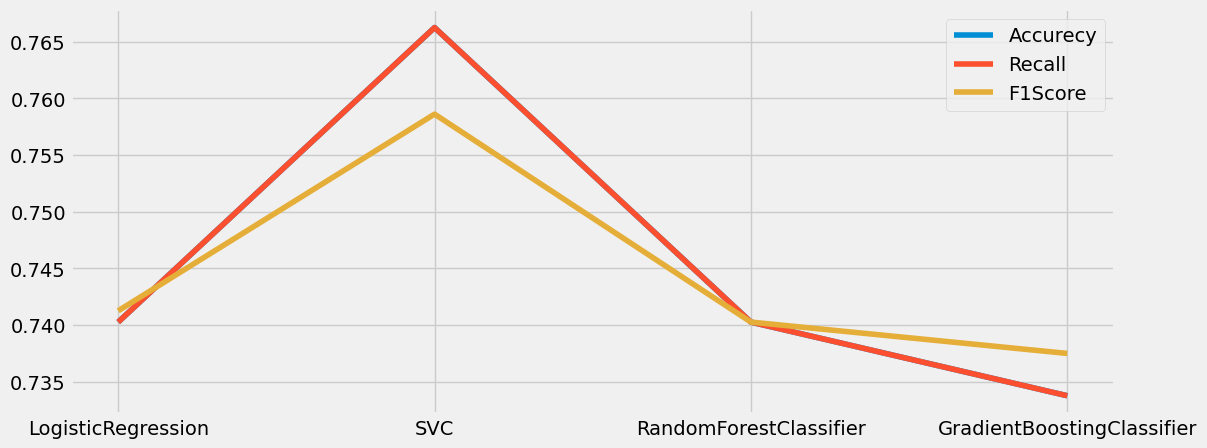

In [50]:
fig, ax =plt.subplots(figsize=(12, 5))
plt.plot(compare.Algorithem, r1, label='Accurecy')
plt.plot(compare.Algorithem, r2, label='Recall')
plt.plot(compare.Algorithem, r3, label='F1Score')

plt.legend()
# plt.ylim(0, 1)
plt.show()


In [51]:
r1


[0.7402597402597403,
 0.7662337662337663,
 0.7402597402597403,
 0.7337662337662337]

## Enhance the results

In [52]:
check_max_data = df[df['Outcome'] == 0]
check_mini_data = df[df['Outcome'] == 1]
check_max_data.shape , check_mini_data.shape

((500, 9), (268, 9))

In [53]:
# for percentage
268 / (500 + 268)*100

34.89583333333333

 > **The data not Balanced**
 >
 >  1. **will use RandomForestClassifier**
 >  2. Balanced using RandomOverSampler